<a href="https://colab.research.google.com/github/gladysandr/dsga-celeratesschool-assignments/blob/main/Tugas%20Asynchronous%205_DSGA_Gladys%20Andromeda%20Bilqis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TUGAS CAMP BATCH 4 CELERATES SCHOOL**

**Data Science & Generative AI (DSGA)**

**Tugas Asynchronous 5: Applied Deep Learning**

Nama: Gladys Andromeda Bilqis

Mentor Personal: Hana Jatmiana

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from keras import layers, callbacks, regularizers
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
df = pd.read_csv('Automobile_data.csv', na_values='?')

print('\nShape:', df.shape)
print('\nFirst 5 rows:')
display(df.head(5))

print("\nMissing values:")
print(df.isnull().sum())


Shape: (205, 26)

First 5 rows:


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0



Missing values:
symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


In [ ]:
df = df.dropna(subset=['price'])
df = df.fillna(df.median(numeric_only=True))

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nAfter handling missing values:")
print(df.isnull().sum())


After handling missing values:
symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

print("\nX preview:")
print(X.head())

print("\ny preview:")
print(y.head())


X preview:
   symboling  normalized-losses  wheel-base  length  width  height  \
0          3              115.0        88.6   168.8   64.1    48.8   
1          3              115.0        88.6   168.8   64.1    48.8   
2          1              115.0        94.5   171.2   65.5    52.4   
3          2              164.0        99.8   176.6   66.2    54.3   
4          2              164.0        99.4   176.6   66.4    54.3   

   curb-weight  engine-size  bore  stroke  ...  num-of-cylinders_three  \
0         2548          130  3.47    2.68  ...                   False   
1         2548          130  3.47    2.68  ...                   False   
2         2823          152  2.68    3.47  ...                   False   
3         2337          109  3.19    3.40  ...                   False   
4         2824          136  3.19    3.40  ...                   False   

   num-of-cylinders_twelve  num-of-cylinders_two  fuel-system_2bbl  \
0                    False                 False    

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (160, 64)
Test shape : (41, 64)


In [ ]:
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

In [ ]:
def get_callbacks():
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=30,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=20, min_lr=1e-6, verbose=0),
    ]

In [ ]:
print("\n================ MODEL 1 ================\n")

model1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],),
          kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dense(1)
], name='Model_1')

model1.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Model 1 Summary:")
model1.summary()

print("\nTraining Model 1...\n")
history1 = model1.fit(
    X_train, y_train_scaled,
    validation_split=0.2,
    epochs=500,
    batch_size=16,
    callbacks=get_callbacks(),
    verbose=0
)
print(f"Model 1 stopped at epoch {len(history1.history['loss'])}")


================ MODEL 1 ================

Model 1 Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 128 (512.00 B)


Training Model 1...

Model 1 stopped at epoch 352


In [ ]:
print("\n================ MODEL 2 ================\n")

model2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],),
          kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dense(1)
], name='Model_2')

model2.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Model 2 Summary:")
model2.summary()

print("\nTraining Model 2...\n")
history2 = model2.fit(
    X_train, y_train_scaled,
    validation_split=0.2,
    epochs=500,
    batch_size=16,
    callbacks=get_callbacks(),
    verbose=0
)
print(f"Model 2 stopped at epoch {len(history2.history['loss'])}")


================ MODEL 2 ================

Model 2 Summary:


Model: "Model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 384 (1.50 KB)


Training Model 2...

Model 2 stopped at epoch 295


In [ ]:
y_pred1 = scaler_y.inverse_transform(model1.predict(X_test)).ravel()
y_pred2 = scaler_y.inverse_transform(model2.predict(X_test)).ravel()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


In [ ]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, r2, mape

mae1, rmse1, r2_1, mape1 = evaluate(y_test, y_pred1)
mae2, rmse2, r2_2, mape2 = evaluate(y_test, y_pred2)

results = pd.DataFrame({
    'Model'   : ['Model 1', 'Model 2'],
    'MAE'     : [mae1, mae2],
    'RMSE'    : [rmse1, rmse2],
    'R²'      : [r2_1, r2_2],
    'MAPE (%)':[mape1, mape2]
})
display(results.set_index('Model').round(4))

,MAE,RMSE,R²,MAPE (%)
Model,,,,
Model 1,1674.8739,3464.9343,0.9019,9.9858
Model 2,2059.8516,3770.7100,0.8838,10.8033


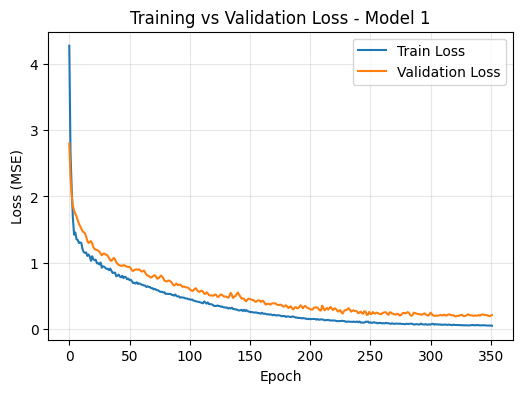

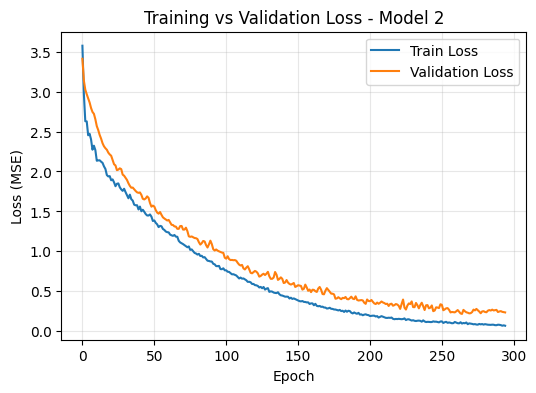

In [ ]:
# Model 1
plt.figure(figsize=(6,4))

plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss - Model 1')

plt.legend()
plt.grid(alpha=0.3)

# Model 2
plt.show()

plt.figure(figsize=(6,4))

plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss - Model 2')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

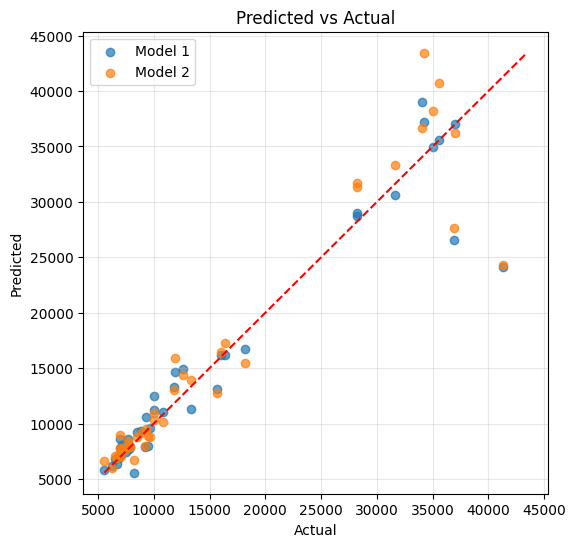

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred1, label='Model 1', alpha=0.7)
plt.scatter(y_test, y_pred2, label='Model 2', alpha=0.7)

min_val = min(y_test.min(), y_pred1.min(), y_pred2.min())
max_val = max(y_test.max(), y_pred1.max(), y_pred2.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.title('Predicted vs Actual')
plt.show()

In [ ]:
best_model = 'Model 1' if r2_1 > r2_2 else 'Model 2'

if best_model == 'Model 1':
    print(f"Best Model : {best_model}")
    print(f"Best R²    : {r2_1:.4f}")
    print(f"Best RMSE  : {rmse1:.4f}")
    print(f"Best MAE   : {mae1:.4f}")
    print(f"Best MAPE  : {mape1:.4f}%")
else:
    print(f"Best Model : {best_model}")
    print(f"Best R²    : {r2_2:.4f}")
    print(f"Best RMSE  : {rmse2:.4f}")
    print(f"Best MAE   : {mae2:.4f}")
    print(f"Best MAPE  : {mape2:.4f}%")

Best Model : Model 1
Best R²    : 0.9019
Best RMSE  : 3464.9343
Best MAE   : 1674.8739
Best MAPE  : 9.9858%


Berdasarkan hasil perbandingan, Model 1 menunjukkan performa terbaik dibandingkan Model 2. Hal ini terlihat dari nilai R² yang mencapai sekitar 0,90, serta nilai MAE, RMSE, dan MAPE yang lebih rendah, yang menandakan bahwa prediksi Model 1 lebih akurat dan stabil. Dari visualisasi, grafik training dan validation loss menunjukkan penurunan yang konsisten tanpa indikasi overfitting yang signifikan, serta plot predicted vs actual memperlihatkan bahwa hasil prediksi Model 1 lebih mendekati garis ideal. Meskipun Model 2 memiliki arsitektur yang lebih kompleks, Model 1 yang lebih sederhana justru lebih efektif dalam menangkap pola data. Hal ini menunjukkan bahwa kompleksitas model tidak selalu menghasilkan performa yang lebih baik, terutama pada dataset dengan jumlah data yang terbatas.